In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import tf2onnx
import netron
import subprocess

# 1. 加载原始 .keras 模型
model = tf.keras.models.load_model(r"cnn_lstm_model.keras")

# 2. 先临时保存为 .keras 格式（Keras 3 需要）
temp_keras_path = "temp_model.keras"
model.save(temp_keras_path)  # Keras 3 默认保存为 .keras 格式

# 3. 重新加载并保存为 SavedModel（tf2onnx 需要的格式）
saved_model_dir = "temp_saved_model"  # 必须是目录，不能有扩展名
model = tf.keras.models.load_model(temp_keras_path)
model.export(saved_model_dir)  # 不指定 save_format，Keras 3 会自动检测 SavedModel

# 4. 转换为 ONNX
onnx_output_path = r"cnn_lstm_model.onnx"
conversion_command = [
    "python", "-m", "tf2onnx.convert",
    "--saved-model", saved_model_dir,
    "--output", onnx_output_path,
    "--tag", "serve"  # 明确指定 tag
]

# 运行转换命令
result = subprocess.run(conversion_command, capture_output=True, text=True)

# 检查错误
if result.returncode != 0:
    print("转换失败:")
    print(result.stderr)
else:
    print("模型成功转换为 ONNX。")

# 用 Netron 可视化
if os.path.exists(onnx_output_path):
    netron.start(onnx_output_path)
else:
    print(f"ONNX 文件 {onnx_output_path} 未生成。")

# 清理临时文件（可选）
os.remove(temp_keras_path)

INFO:tensorflow:Assets written to: temp_saved_model\assets


INFO:tensorflow:Assets written to: temp_saved_model\assets


Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 158), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2592787846096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2592787847248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2592787846864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2592787848208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2592787848976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2592787847440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2592787848592: TensorSpec(shape=(), dtype=tf.resource, name=None)
模型成功转换为 ONNX。
Serving 'cnn_lstm_model.onnx' at http://localhost:8080


In [2]:
import numpy as np
import pandas as pd
import time
import pickle
import inspect
import importlib
from tqdm import tqdm  # 导入 tqdm
import torch
import os
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

data = pd.read_parquet('C:\\Users\\36119\\Desktop\\CEF2\\CEF2_project\\data\\Fature_factor_data_1600.parquet')
factor = pd.read_parquet('C:\\Users\\36119\\Desktop\\CEF2\\CEF2_project\\data\\Factor_compute_1600.parquet')


# 假设 df 是你的 DataFrame

# 1. 提取 factor 列
factor_cols = [col for col in factor.columns if col.startswith('factor_')]

# 2. 计算每个 date_id 的所有 factor 的均值
daily_avg = factor.groupby('date_id')[factor_cols].mean().shift(1)  # 滞后一天

# 3. 将滞后后的 daily_avg 合并回原 DataFrame
# 先把 daily_avg 的索引变成列
daily_avg = daily_avg.reset_index().dropna()
daily_avg.columns = ['date_id'] + [f + '_lag1' for f in factor_cols]  # 重命名列

# 4. 合并
df_merged = pd.merge(data, daily_avg, on='date_id', how='left')
data=[]
daily_avg=[]


# 初始化一个空的 DataFrame（用于逐列添加）
df_new = pd.DataFrame()

# 添加四个基础列
for col in ['date_id', 'time_id', 'symbol_id', 'weight']:
    if col in df_merged.columns:
        df_new[col] = df_merged[col]

# 添加 factor_xx 和 factor_xx_lag1 交替顺序
for i in range(79):  # 00 到 78
    f = f'feature_{i:02d}'
    lag = f'factor_{i:02d}_lag1'
    
    if f in df_merged.columns:
        df_new[f] = df_merged[f]
    if lag in df_merged.columns:
        df_new[lag] = df_merged[lag]

df_new['responder_6'] = df_merged['responder_6']


C:\Users\36119\AppData\Local\Temp\ipykernel_980\4170120695.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[f] = df_merged[f]
C:\Users\36119\AppData\Local\Temp\ipykernel_980\4170120695.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_new[lag] = df_merged[lag]
C:\Users\36119\AppData\Local\Temp\ipykernel_980\4170120695.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using 

In [3]:
df_new=df_new[df_new['date_id'] >= 1668]

Processing sequences: 100%|██████████| 1194/1194 [00:01<00:00, 624.76it/s]


✅ 数据形状 X: (1145046, 10, 158), y: (1145046,), weights: (1145046,)
训练集: (916036, 10, 158), 验证集: (114505, 10, 158), 测试集: (114505, 10, 158)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 158)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 79, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 78, 4)      │            20 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 312)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,597 (377.33 KB)

 Trainable params: 96,597 (377.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
895/895 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.2604
Epoch 1: val_loss improved from inf to 0.94331, saving model to cnn_lstm_model.keras
895/895 ━━━━━━━━━━━━━━━━━━━━ 35s 36ms/step - loss: 1.2603 - val_loss: 0.9433 - learning_rate: 2.0000e-05
Epoch 2/30
894/895 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.0925
Epoch 2: val_loss improved from 0.94331 to 0.94111, saving model to cnn_lstm_model.keras
895/895 ━━━━━━━━━━━━━━━━━━━━ 35s 39ms/step - loss: 1.0925 - val_loss: 0.9411 - learning_rate: 2.0000e-05
Epoch 3/30
894/895 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.0828
Epoch 3: val_loss improved from 0.94111 to 0.93970, saving model to cnn_lstm_model.keras
895/895 ━━━━━━━━━━━━━━━━━━━━ 51s 57ms/step - loss: 1.0828 - val_loss: 0.9397 - learning_rate: 2.0000e-05
Epoch 4/30
895/895 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.0820
Epoch 4: val_loss improved from 0.93970 to 0.93784, saving model to cnn_lstm_model.keras
895/895 ━━━━━━━━━━━━━━━━━━━━ 52s 58ms/step - loss: 1.0820 - v

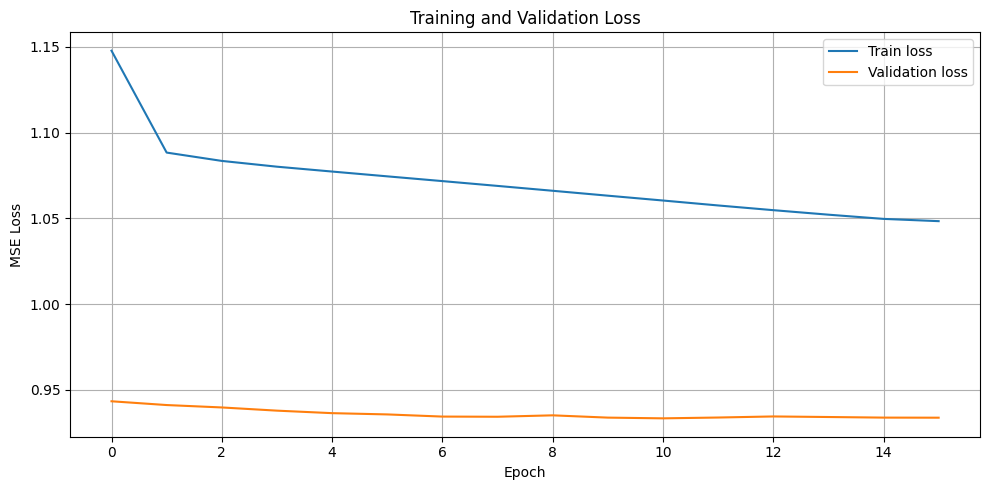

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
✅ Validation set R² Score: 0.005647
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
✅ Test set R² Score: 0.002631
✅ 模型已保存至 cnn_lstm_model.keras


In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import os

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 1024
EPOCHS = 30
MODEL_PATH = 'cnn_lstm_model.keras'

# ==============================
# 构造特征名
features = []
for i in range(79):
    features.append(f'feature_{i:02d}')
    features.append(f'factor_{i:02d}_lag1')  # 每个 feature 对应一个 lag 特征

NUM_FEATURES = len(features)  # 158

# ==============================

df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)  # [样本数, SEQ_LEN, 158]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 划分训练集、验证集、测试集 (8:1:1)
num_samples = len(X)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)

X_train, y_train, w_train = X[:train_end], y[:train_end], weights[:train_end]
X_val, y_val, w_val = X[train_end:val_end], y[train_end:val_end], weights[train_end:val_end]
X_test, y_test, w_test = X[val_end:], y[val_end:], weights[val_end:]

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")


# ==============================
# 构建模型：Conv1D + LSTM
def build_conv_fusion_cnn_lstm(input_shape):
    # input_shape: (SEQ_LEN, 158)
    inputs = Input(shape=input_shape)  # [batch, seq_len, 158]
    
    # 1. reshape: 每个时间点变成 79x2
    x = Reshape((input_shape[0], 79, 2))(inputs)  # [batch, seq_len, 79, 2]

    # 2. 卷积合并：对每对特征做 Conv1D
    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)  # [batch, seq_len, 79, 1 → 4]

    # 3. 展平为向量
    x = TimeDistributed(Flatten())(x)  # [batch, seq_len, 4*78] = [batch, seq_len, 316]

    # 4. LSTM 提取时序特征
    x = LSTM(64, return_sequences=False)(x)

    # 5. 回归输出
    outputs = Dense(1)(x)
    return Model(inputs, outputs)
from tensorflow.keras.layers import BatchNormalization, Dropout


# ========== 编译模型 ==========
model = build_conv_fusion_cnn_lstm(X_train.shape[1:])
model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='mse'
)
model.summary()

# ========== 设置回调函数 ==========
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# ========== 模型训练 ==========
history = model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_val, y_val, w_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks
)


# ========== 绘制训练损失曲线 ==========
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ========== 验证集评估 ==========
y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()

def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
print(f"✅ Validation set R² Score: {r2_val:.6f}")

# ========== 测试集评估 ==========
y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE).squeeze()
r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
print(f"✅ Test set R² Score: {r2_test:.6f}")

# ========== 模型保存 ==========
model.save(MODEL_PATH)
print(f"✅ 模型已保存至 {MODEL_PATH}")


In [8]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import os

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 1024
EPOCHS = 30
MODEL_PATH = 'cnn_lstm_model.keras'

# ==============================
# 构造特征名
features = []
for i in range(79):
    features.append(f'feature_{i:02d}')
    features.append(f'factor_{i:02d}_lag1')  # 每个 feature 对应一个 lag 特征

NUM_FEATURES = len(features)  # 158

# ==============================

df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)  # [样本数, SEQ_LEN, 158]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 划分训练集、验证集、测试集 (8:1:1)
num_samples = len(X)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)

X_train, y_train, w_train = X[:train_end], y[:train_end], weights[:train_end]
X_val, y_val, w_val = X[train_end:val_end], y[train_end:val_end], weights[train_end:val_end]
X_test, y_test, w_test = X[val_end:], y[val_end:], weights[val_end:]

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")

Processing sequences: 100%|██████████| 1194/1194 [00:02<00:00, 575.93it/s]


✅ 数据形状 X: (1145046, 10, 158), y: (1145046,), weights: (1145046,)
训练集: (916036, 10, 158), 验证集: (114505, 10, 158), 测试集: (114505, 10, 158)


In [9]:
import itertools
import json
import os

# ========== 定义超参数网格 ==========
param_grid = {
    'learning_rate': [2e-5, 1e-4, 5e-4],
    'lstm_units': [32, 64, 128],
    'conv_filters': [4, 8],
    'kernel_size': [2, 3],
    'batch_size': [512, 1024]
}

# ========== 网格搜索生成超参数组合 ==========
def generate_param_combinations(grid):
    keys, values = zip(*grid.items())
    experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]
    return experiments

experiments = generate_param_combinations(param_grid)
print(f"共 {len(experiments)} 组超参数组合")

# ========== 构建模型函数（带参数） ==========
def build_model(input_shape, conv_filters, kernel_size, lstm_units):
    inputs = Input(shape=input_shape)
    x = Reshape((input_shape[0], 79, 2))(inputs)
    x = TimeDistributed(Conv1D(filters=conv_filters, kernel_size=kernel_size, activation='relu'))(x)
    x = TimeDistributed(Flatten())(x)
    x = LSTM(lstm_units, return_sequences=False)(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs)

# ========== 训练与评估函数 ==========
def train_and_evaluate(params, exp_id):
    print(f"\n🔵 开始实验 {exp_id}: {params}")
    
    model = build_model(
        input_shape=X_train.shape[1:],
        conv_filters=params['conv_filters'],
        kernel_size=params['kernel_size'],
        lstm_units=params['lstm_units']
    )
    
    model.compile(
        optimizer=Adam(learning_rate=params['learning_rate']),
        loss='mse'
    )
    
    # 回调
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
        ModelCheckpoint(filepath=f"model_exp_{exp_id}.keras", monitor='val_loss', save_best_only=True, verbose=0)
    ]
    
    # 训练
    history = model.fit(
        X_train, y_train,
        sample_weight=w_train,
        validation_data=(X_val, y_val, w_val),
        epochs=EPOCHS,
        batch_size=params['batch_size'],
        verbose=0,
        callbacks=callbacks
    )
    
    # 预测
    y_pred_val = model.predict(X_val, batch_size=params['batch_size']).squeeze()
    y_pred_test = model.predict(X_test, batch_size=params['batch_size']).squeeze()

    # 打分
    r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
    r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
    
    # 保存实验记录
    result = {
        'exp_id': exp_id,
        'params': params,
        'r2_val': r2_val,
        'r2_test': r2_test,
        'final_val_loss': history.history['val_loss'][-1]
    }
    
    with open(f"result_exp_{exp_id}.json", 'w') as f:
        json.dump(result, f, indent=4)
        
    print(f"✅ 实验 {exp_id} 完成: Validation R² = {r2_val:.6f}, Test R² = {r2_test:.6f}")
    return result

# ========== 主循环跑所有实验 ==========
all_results = []
os.makedirs('experiments', exist_ok=True)
os.chdir('experiments')

for idx, params in enumerate(experiments):
    result = train_and_evaluate(params, exp_id=idx)
    all_results.append(result)

# ========== 保存所有实验的汇总 ==========
with open('all_experiment_results.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("\n🎯 所有实验已完成，结果保存至 experiments/ 文件夹。")


共 72 组超参数组合

🔵 开始实验 0: {'learning_rate': 2e-05, 'lstm_units': 32, 'conv_filters': 4, 'kernel_size': 2, 'batch_size': 512}
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
✅ 实验 0 完成: Validation R² = 0.002716, Test R² = 0.001985

🔵 开始实验 1: {'learning_rate': 2e-05, 'lstm_units': 32, 'conv_filters': 4, 'kernel_size': 2, 'batch_size': 1024}
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
✅ 实验 1 完成: Validation R² = 0.002896, Test R² = 0.001793

🔵 开始实验 2: {'learning_rate': 2e-05, 'lstm_units': 32, 'conv_filters': 4, 'kernel_size': 3, 'batch_size': 512}
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
✅ 实验 2 完成: Validation R² = 0.006467, Test R² = 0.003135

🔵 开始实验 3: {'learning_rate': 2e-05, 'lstm_units': 32, 'conv_filters': 4, 'kernel_size': 3, 'batch_size': 1024}
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
✅ 实验 3 完成: Validation R² = -0.000766, Test R² =

Processing sequences: 100%|██████████| 1194/1194 [00:01<00:00, 657.24it/s]


✅ 数据形状 X: (1145046, 10, 79), y: (1145046,), weights: (1145046,)
训练集: (916036, 10, 79), 验证集: (114505, 10, 79), 测试集: (114505, 10, 79)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 79)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 10, 79, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 78, 4)      │            12 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 312)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,589 (377.30 KB)

 Trainable params: 96,589 (377.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
895/895 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.2692
Epoch 1: val_loss improved from inf to 0.94863, saving model to cnn_lstm_model_no_lag.keras
895/895 ━━━━━━━━━━━━━━━━━━━━ 43s 45ms/step - loss: 1.2691 - val_loss: 0.9486 - learning_rate: 2.0000e-05
Epoch 2/30
894/895 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.0912
Epoch 2: val_loss improved from 0.94863 to 0.94079, saving model to cnn_lstm_model_no_lag.keras
895/895 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - loss: 1.0912 - val_loss: 0.9408 - learning_rate: 2.0000e-05
Epoch 3/30
895/895 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1.0889
Epoch 3: val_loss improved from 0.94079 to 0.93911, saving model to cnn_lstm_model_no_lag.keras
895/895 ━━━━━━━━━━━━━━━━━━━━ 53s 59ms/step - loss: 1.0889 - val_loss: 0.9391 - learning_rate: 2.0000e-05
Epoch 4/30
895/895 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1.0870
Epoch 4: val_loss improved from 0.93911 to 0.93897, saving model to cnn_lstm_model_no_lag.keras
895/895 ━━━━━━━━━━━━━━━━━━━━ 49s 

C:\Users\36119\AppData\Local\Temp\ipykernel_980\86247394.py:116: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_980\86247394.py:116: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_980\86247394.py:116: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_980\86247394.py:116: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_980\86247394.py:116: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_980\86247394.py:116: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from current f

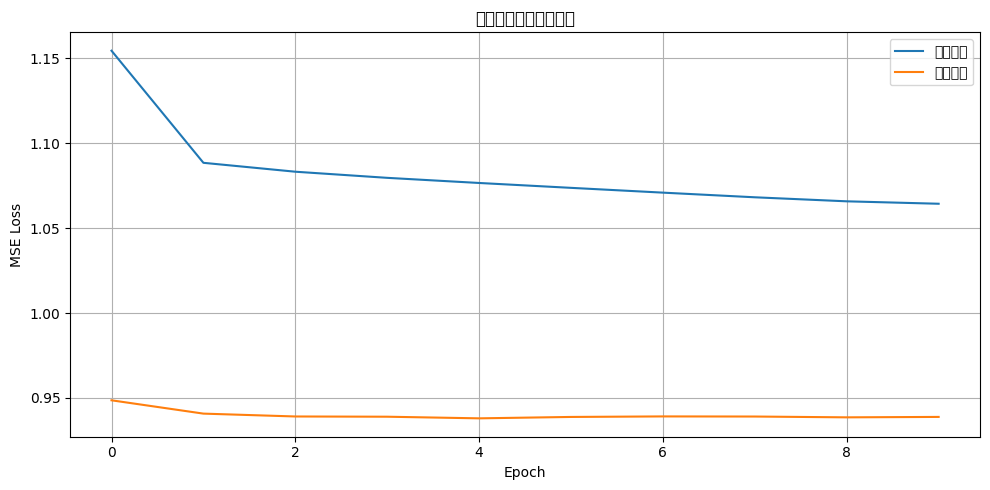

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
✅ 验证集上的加权 R² Score: 0.000684
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
✅ 测试集上的加权 R² Score: 0.001885
✅ 模型已保存至 cnn_lstm_model_no_lag.keras


In [6]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 1024
EPOCHS = 30
MODEL_PATH = 'cnn_lstm_model_no_lag.keras'

# ==============================
# 构造特征名（只用原始 feature）
features = [f'feature_{i:02d}' for i in range(79)]
NUM_FEATURES = len(features)  # 79

# ==============================
# 按照 symbol_id/date_id/time_id 排序
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)        # [样本数, SEQ_LEN, 79]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 划分训练集、验证集、测试集 (8:1:1)
num_samples = len(X)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)

X_train, y_train, w_train = X[:train_end], y[:train_end], weights[:train_end]
X_val, y_val, w_val = X[train_end:val_end], y[train_end:val_end], weights[train_end:val_end]
X_test, y_test, w_test = X[val_end:], y[val_end:], weights[val_end:]

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")

# ==============================
# 构建模型：Conv1D + LSTM
def build_conv_fusion_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)  # [batch, seq_len, 79]
    
    x = Reshape((input_shape[0], 79, 1))(inputs)  # [batch, seq_len, 79, 1]

    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)  # [batch, seq_len, 78, 4]
    x = TimeDistributed(Flatten())(x)  # [batch, seq_len, 78*4] = [batch, seq_len, 312]

    x = LSTM(64, return_sequences=False)(x)
    outputs = Dense(1)(x)

    return Model(inputs, outputs)

# ==============================
# 构建、编译模型
model = build_conv_fusion_cnn_lstm(X_train.shape[1:])
model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='mse'
)
model.summary()

# ==============================
# 回调函数
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=2e-6, verbose=1),
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]

# ==============================
# 模型训练
history = model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_val, y_val, w_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks
)

# ==============================
# 损失曲线可视化
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('训练过程中的损失变化')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# R² 加权评估函数
def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

# ==============================
# 验证集评估
y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()
r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
print(f"✅ 验证集上的加权 R² Score: {r2_val:.6f}")

# 测试集评估
y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE).squeeze()
r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
print(f"✅ 测试集上的加权 R² Score: {r2_test:.6f}")

# ==============================
# 保存最终模型（可省略，已经通过 ModelCheckpoint 保存了最优模型）
model.save(MODEL_PATH)
print(f"✅ 模型已保存至 {MODEL_PATH}")


In [ ]:

# ==============================
# 构建模型：Conv1D + LSTM
def build_conv_fusion_cnn_lstm(input_shape):
    # input_shape: (SEQ_LEN, 158)
    inputs = Input(shape=input_shape)  # [batch, seq_len, 158]
    
    # 1. reshape: 每个时间点变成 79x2
    x = Reshape((input_shape[0], 79, 2))(inputs)  # [batch, seq_len, 79, 2]

    # 2. 卷积合并：对每对特征做 Conv1D
    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)  # [batch, seq_len, 79, 1 → 4]

    # 3. 展平为向量
    x = TimeDistributed(Flatten())(x)  # [batch, seq_len, 4*78] = [batch, seq_len, 316]

    # 4. LSTM 提取时序特征
    x = LSTM(64, return_sequences=False)(x)

    # 5. 回归输出
    outputs = Dense(1)(x)
    return Model(inputs, outputs)
from tensorflow.keras.layers import BatchNormalization, Dropout

# def build_conv_fusion_cnn_lstm(input_shape):
#     inputs = Input(shape=input_shape)  # [batch, SEQ_LEN, 158]
    
#     # 1. reshape 为 [batch, SEQ_LEN, 79, 2]
#     x = Reshape((input_shape[0], 79, 2))(inputs)

#     # 2. TimeDistributed Conv1D 提取局部特征（堆叠两层，减少滤波器数量）
#     x = TimeDistributed(Conv1D(filters=8, kernel_size=2, activation='relu', padding='valid'))(x)
#     x = TimeDistributed(BatchNormalization())(x)
#     x = TimeDistributed(Dropout(0.2))(x)

#     x = TimeDistributed(Conv1D(filters=16, kernel_size=2, activation='relu', padding='valid'))(x)
#     x = TimeDistributed(BatchNormalization())(x)
#     x = TimeDistributed(Dropout(0.2))(x)

#     # 3. 展平为向量 [batch, SEQ_LEN, flattened dim]
#     x = TimeDistributed(Flatten())(x)

#     # 4. LSTM 层提取时序特征（1层 LSTM）
#     x = LSTM(64, return_sequences=False)(x)

#     # 5. Dense 层增强特征表达（减少神经元数量）
#     x = Dense(32, activation='relu')(x)
#     x = Dropout(0.2)(x)

#     # 6. 输出回归值
#     outputs = Dense(1)(x)

#     return Model(inputs, outputs)


# ========== 编译模型 ==========
model = build_conv_fusion_cnn_lstm(X_train.shape[1:])
model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='mse'
)
model.summary()

# ========== 设置回调函数 ==========
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# ========== 模型训练 ==========
history = model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_val, y_val, w_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks
)


# ========== 绘制训练损失曲线 ==========
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ========== 验证集评估 ==========
y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()

def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
print(f"✅ Validation set R² Score: {r2_val:.6f}")

# ========== 测试集评估 ==========
y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE).squeeze()
r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
print(f"✅ Test set R² Score: {r2_test:.6f}")

# ========== 模型保存 ==========
model.save(MODEL_PATH)
print(f"✅ 模型已保存至 {MODEL_PATH}")

Processing sequences: 100%|██████████| 3765/3765 [00:06<00:00, 569.82it/s]


✅ 数据形状 X: (3610635, 10, 79), y: (3610635,), weights: (3610635,)
训练集: (2888508, 10, 79), 验证集: (361063, 10, 79), 测试集: (361064, 10, 79)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 79)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 10, 79, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 78, 4)      │            12 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 312)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,589 (377.30 KB)

 Trainable params: 96,589 (377.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.5547
Epoch 1: val_loss improved from inf to 1.19629, saving model to cnn_lstm_model_no_lag.keras
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 149s 51ms/step - loss: 1.5547 - val_loss: 1.1963 - learning_rate: 2.0000e-05
Epoch 2/30
2820/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.4360
Epoch 2: val_loss improved from 1.19629 to 1.19519, saving model to cnn_lstm_model_no_lag.keras
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 163s 58ms/step - loss: 1.4360 - val_loss: 1.1952 - learning_rate: 2.0000e-05
Epoch 3/30
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.4293
Epoch 3: val_loss improved from 1.19519 to 1.19296, saving model to cnn_lstm_model_no_lag.keras
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 140s 50ms/step - loss: 1.4293 - val_loss: 1.1930 - learning_rate: 2.0000e-05
Epoch 4/30
2820/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1.4245
Epoch 4: val_loss improved from 1.19296 to 1.19270, saving model to cnn_lstm_model_no_lag.keras
2821/2821 ━━━━━━

C:\Users\36119\AppData\Local\Temp\ipykernel_45624\86247394.py:116: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\86247394.py:116: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\86247394.py:116: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\86247394.py:116: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\86247394.py:116: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\86247394.py:116: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing fr

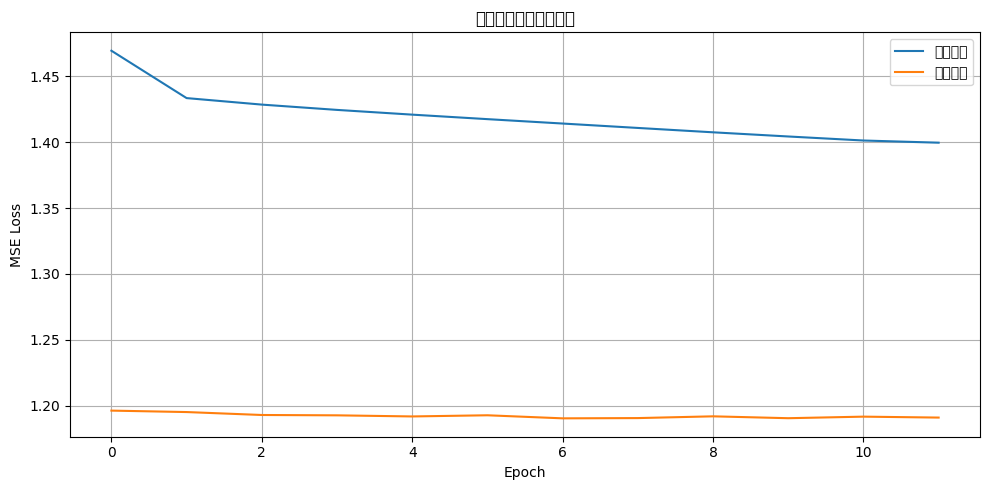

353/353 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
✅ 验证集上的加权 R² Score: 0.004339
353/353 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step
✅ 测试集上的加权 R² Score: 0.000798
✅ 模型已保存至 cnn_lstm_model_no_lag.keras


In [8]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 1024
EPOCHS = 30
MODEL_PATH = 'cnn_lstm_model_no_lag.keras'

# ==============================
# 构造特征名（只用原始 feature）
features = [f'feature_{i:02d}' for i in range(79)]
NUM_FEATURES = len(features)  # 79

# ==============================
# 按照 symbol_id/date_id/time_id 排序
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)        # [样本数, SEQ_LEN, 79]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 划分训练集、验证集、测试集 (8:1:1)
num_samples = len(X)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)

X_train, y_train, w_train = X[:train_end], y[:train_end], weights[:train_end]
X_val, y_val, w_val = X[train_end:val_end], y[train_end:val_end], weights[train_end:val_end]
X_test, y_test, w_test = X[val_end:], y[val_end:], weights[val_end:]

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")

# ==============================
# 构建模型：Conv1D + LSTM
def build_conv_fusion_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)  # [batch, seq_len, 79]
    
    x = Reshape((input_shape[0], 79, 1))(inputs)  # [batch, seq_len, 79, 1]

    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)  # [batch, seq_len, 78, 4]
    x = TimeDistributed(Flatten())(x)  # [batch, seq_len, 78*4] = [batch, seq_len, 312]

    x = LSTM(64, return_sequences=False)(x)
    outputs = Dense(1)(x)

    return Model(inputs, outputs)

# ==============================
# 构建、编译模型
model = build_conv_fusion_cnn_lstm(X_train.shape[1:])
model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='mse'
)
model.summary()

# ==============================
# 回调函数
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=2e-6, verbose=1),
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]

# ==============================
# 模型训练
history = model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_val, y_val, w_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks
)

# ==============================
# 损失曲线可视化
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('训练过程中的损失变化')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# R² 加权评估函数
def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

# ==============================
# 验证集评估
y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()
r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
print(f"✅ 验证集上的加权 R² Score: {r2_val:.6f}")

# 测试集评估
y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE).squeeze()
r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
print(f"✅ 测试集上的加权 R² Score: {r2_test:.6f}")

# ==============================
# 保存最终模型（可省略，已经通过 ModelCheckpoint 保存了最优模型）
model.save(MODEL_PATH)
print(f"✅ 模型已保存至 {MODEL_PATH}")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 1024
EPOCHS = 30
MODEL_PATH = 'cnn_lstm_model_no_lag.pth'

# ==============================
# 构造特征名（只用原始 feature）
features = [f'feature_{i:02d}' for i in range(79)]
NUM_FEATURES = len(features)  # 79

# ==============================
# 按照 symbol_id/date_id/time_id 排序
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)        # [样本数, SEQ_LEN, 79]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 划分训练集、验证集、测试集 (8:1:1)
num_samples = len(X)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)

X_train, y_train, w_train = X[:train_end], y[:train_end], weights[:train_end]
X_val, y_val, w_val = X[train_end:val_end], y[train_end:val_end], weights[train_end:val_end]
X_test, y_test, w_test = X[val_end:], y[val_end:], weights[val_end:]

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")

# ==============================
# 将数据转为 PyTorch 的 TensorDataset
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train), torch.tensor(w_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val), torch.tensor(w_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test), torch.tensor(w_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==============================
# 定义模型（复杂化 CNN + LSTM）
class CNNLSTM(nn.Module):
    def __init__(self, input_size, seq_len, hidden_size=64, num_filters=8, kernel_size=3):
        super(CNNLSTM, self).__init__()
        # Conv1D layers
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=num_filters, kernel_size=kernel_size, stride=1, padding=1)
        self.conv2 = nn.Conv1d(in_channels=num_filters, out_channels=num_filters * 2, kernel_size=kernel_size, stride=1, padding=1)
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size=num_filters * 2, hidden_size=hidden_size, batch_first=True)
        
        # Dense layer
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # [batch, seq_len, num_features] -> [batch, num_features, seq_len] for Conv1d
        x = x.permute(0, 2, 1)
        
        # Convolutional layers
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        
        # Flatten the output of Conv layers, adjusting for LSTM input
        x = x.permute(0, 2, 1)  # Reshape back to [batch_size, seq_len, num_features] for LSTM
        
        # LSTM
        x, (hn, cn) = self.lstm(x)
        
        # Output
        x = self.fc(hn[-1])  # We take the last hidden state
        
        return x


# ==============================
# 定义加权 R² Score
def weighted_r2_score(y_true, y_pred, weight):
    y_bar = torch.sum(weight * y_true) / torch.sum(weight)
    ss_tot = torch.sum(weight * (y_true - y_bar) ** 2)
    ss_res = torch.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

# ==============================
# 构建、编译模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNLSTM(input_size=NUM_FEATURES, seq_len=SEQ_LEN).to(device)

# 定义损失函数和优化器
criterion = nn.MSELoss(reduction='none')  # 需要加权损失
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ==============================
# 训练模型
def train(model, train_loader, val_loader, epochs=EPOCHS):
    best_val_r2 = -np.inf
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch, w_batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
            X_batch, y_batch, w_batch = X_batch.to(device), y_batch.to(device), w_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch)
            
            loss = criterion(y_pred.squeeze(), y_batch)
            weighted_loss = torch.sum(loss * w_batch) / torch.sum(w_batch)  # 加权损失
            weighted_loss.backward()
            optimizer.step()
            
            running_loss += weighted_loss.item()
        
        train_loss = running_loss / len(train_loader)
        history['train_loss'].append(train_loss)
        
        # 验证集评估
        model.eval()
        val_loss = 0.0
        val_r2 = 0.0
        with torch.no_grad():
            for X_batch, y_batch, w_batch in val_loader:
                X_batch, y_batch, w_batch = X_batch.to(device), y_batch.to(device), w_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred.squeeze(), y_batch)
                weighted_loss = torch.sum(loss * w_batch) / torch.sum(w_batch)
                val_loss += weighted_loss.item()
                
                # 计算 R²
                val_r2 += weighted_r2_score(y_batch, y_pred.squeeze(), w_batch).item()
        
        val_loss /= len(val_loader)
        val_r2 /= len(val_loader)
        
        history['val_loss'].append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val R²: {val_r2:.4f}")
        
        # 保存最佳模型
        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            torch.save(model.state_dict(), MODEL_PATH)
    
    return history

# 训练模型
history = train(model, train_loader, val_loader, epochs=EPOCHS)

# ==============================
# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='训练损失')
plt.plot(history['val_loss'], label='验证损失')
plt.xlabel('Epoch')
plt.ylabel('加权 MSE 损失')
plt.title('训练过程中的损失变化')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# 评估模型（验证集和测试集）
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# 验证集评估
val_preds = []
val_true = []
val_weights = []
with torch.no_grad():
    for X_batch, y_batch, w_batch in val_loader:
        X_batch, y_batch, w_batch = X_batch.to(device), y_batch.to(device), w_batch.to(device)
        y_pred = model(X_batch)
        val_preds.append(y_pred.squeeze().cpu().numpy())
        val_true.append(y_batch.cpu().numpy())
        val_weights.append(w_batch.cpu().numpy())

val_preds = np.concatenate(val_preds)
val_true = np.concatenate(val_true)
val_weights = np.concatenate(val_weights)
val_r2 = weighted_r2_score(torch.tensor(val_true), torch.tensor(val_preds), torch.tensor(val_weights))
print(f"✅ 验证集上的加权 R² Score: {val_r2:.6f}")

# 测试集评估
test_preds = []
test_true = []
test_weights = []
with torch.no_grad():
    for X_batch, y_batch, w_batch in test_loader:
        X_batch, y_batch, w_batch = X_batch.to(device), y_batch.to(device), w_batch.to(device)
        y_pred = model(X_batch)
        test_preds.append(y_pred.squeeze().cpu().numpy())
        test_true.append(y_batch.cpu().numpy())
        test_weights.append(w_batch.cpu().numpy())

test_preds = np.concatenate(test_preds)
test_true = np.concatenate(test_true)
test_weights = np.concatenate(test_weights)
test_r2 = weighted_r2_score(torch.tensor(test_true), torch.tensor(test_preds), torch.tensor(test_weights))
print(f"✅ 测试集上的加权 R² Score: {test_r2:.6f}")


Processing sequences: 100%|██████████| 3765/3765 [00:05<00:00, 651.10it/s]


✅ 数据形状 X: (3610635, 10, 79), y: (3610635,), weights: (3610635,)
训练集: (2888508, 10, 79), 验证集: (361063, 10, 79), 测试集: (361064, 10, 79)


Epoch 1/30: 100%|██████████| 2821/2821 [00:48<00:00, 58.09it/s]


Epoch 1/30 - Train Loss: 0.5949 - Val Loss: 0.6112 - Val R²: -0.0177


Epoch 2/30: 100%|██████████| 2821/2821 [00:44<00:00, 63.60it/s]


...

Epoch 18/30: 100%|██████████| 2821/2821 [00:44<00:00, 63.03it/s]


Epoch 18/30 - Train Loss: 0.5824 - Val Loss: 0.6191 - Val R²: -0.0232


Epoch 19/30: 100%|██████████| 2821/2821 [00:43<00:00, 64.38it/s]


Epoch 19/30 - Train Loss: 0.5818 - Val Loss: 0.6198 - Val R²: -0.0244


Epoch 20/30: 100%|██████████| 2821/2821 [00:45<00:00, 62.11it/s]


In [12]:
import torch

print("GPU 是否可用:", torch.cuda.is_available())
print("当前使用的 GPU 数量:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("当前使用的 GPU 名称:", torch.cuda.get_device_name(torch.cuda.current_device()))


GPU 是否可用: True
当前使用的 GPU 数量: 1
当前使用的 GPU 名称: NVIDIA GeForce RTX 4060 Laptop GPU


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==============================
# Parameters
SEQ_LEN = 10
BATCH_SIZE = 1024
EPOCHS = 10
MODEL_PATH = 'cnn_lstm_model_with_lr_schedule.pth'

# ==============================
# Define feature names (same as before)
features = [f'feature_{i:02d}' for i in range(79)]
NUM_FEATURES = len(features)

# ==============================
# Prepare the data (same preprocessing as before)
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)        # [num_samples, SEQ_LEN, 79]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ Data shapes: X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# Split data into train, validation, and test sets
num_samples = len(X)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)

X_train, y_train, w_train = X[:train_end], y[:train_end], weights[:train_end]
X_val, y_val, w_val = X[train_end:val_end], y[train_end:val_end], weights[train_end:val_end]
X_test, y_test, w_test = X[val_end:], y[val_end:], weights[val_end:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ==============================
# PyTorch Dataset and DataLoader
train_data = TensorDataset(torch.tensor(X_train), torch.tensor(y_train), torch.tensor(w_train))
val_data = TensorDataset(torch.tensor(X_val), torch.tensor(y_val), torch.tensor(w_val))
test_data = TensorDataset(torch.tensor(X_test), torch.tensor(y_test), torch.tensor(w_test))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

# ==============================
# Define the model: CNN + LSTM
class CNN_LSTM(nn.Module):
    def __init__(self, input_size, seq_len):
        super(CNN_LSTM, self).__init__()
        self.seq_len = seq_len

        # First Conv Layer
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=8, kernel_size=2)
        self.dropout1 = nn.Dropout(0.2)

        # Second Conv Layer
        self.conv2 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=2)
        self.dropout2 = nn.Dropout(0.2)

        # After convolution, the sequence length will be reduced by 2 (kernel_size=2 for both convolutions)
        reduced_seq_len = seq_len - 2 * 2  # seq_len - kernel_size * 2 for each convolution
        
        # LSTM Layer
        # Now LSTM expects the input size to be 16 (output from conv2) and seq_len should be reduced accordingly
        self.lstm1 = nn.LSTM(input_size=16, hidden_size=128, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=128, hidden_size=64, batch_first=True)

        # Output Layer
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        # Change input shape to [batch_size, channels, seq_len] (for Conv1d)
        x = x.permute(0, 2, 1)  # Change to [batch_size, features, seq_len]
        
        # Apply convolutional layers
        x = self.conv1(x)
        x = self.dropout1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = self.dropout2(x)
        x = torch.relu(x)

        # After convolution, the output shape is [batch_size, channels=16, reduced_seq_len]
        # We need to permute it to [batch_size, seq_len, features] for LSTM input
        x = x.permute(0, 2, 1)  # Change to [batch_size, seq_len, features]

        # Pass through LSTM layers
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)

        # Take the last output from LSTM (final time step)
        x = x[:, -1, :]  # shape [batch_size, features] (last time step)

        # Final dense layer for output
        x = self.fc(x)
        return x

# ==============================
# Initialize the model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_LSTM(input_size=79, seq_len=SEQ_LEN).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-3)
loss_fn = nn.MSELoss()

# ==============================
# Learning rate scheduler with warm-up and decay
# 更新学习率调度函数，使其接受 lr 参数
def lr_schedule(epoch, lr):
    if epoch < 5:
        return lr * (epoch + 1) / 5  # 学习率预热
    else:
        return lr * np.exp(-0.1)  # 学习率衰减

# 使用 LambdaLR 调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)


# ==============================
# Training loop
# Train the model
def train(model, train_loader, val_loader, optimizer, loss_fn, scheduler, epochs):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for inputs, targets, weights in train_loader:  # 修改了这里
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            
            # 使用权重加权计算损失
            loss = (loss * weights).mean()  # 如果有权重
            
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        
        train_losses.append(epoch_train_loss / len(train_loader))

        # Validation phase
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for inputs, targets, weights in val_loader:  # 修改了这里
                outputs = model(inputs)
                loss = loss_fn(outputs, targets)
                
                # 如果有权重
                loss = (loss * weights).mean()  # 使用权重加权计算损失
                
                epoch_val_loss += loss.item()

        val_losses.append(epoch_val_loss / len(val_loader))

        # Update learning rate using ReduceLROnPlateau
        scheduler.step(epoch_val_loss)  # 传递验证集的损失

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    
    return train_losses, val_losses


# Train the model
train_losses, val_losses = train(model, train_loader, val_loader, optimizer, loss_fn, scheduler, EPOCHS)


# ==============================
# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# Evaluation
def evaluate(model, test_loader, loss_fn):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for X_batch, y_batch, w_batch in test_loader:
            X_batch, y_batch, w_batch = X_batch.to(device), y_batch.to(device), w_batch.to(device)
            preds = model(X_batch)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Weighted R² score calculation
    def weighted_r2_score(y_true, y_pred, weight):
        # Make sure y_true, y_pred are 1D arrays
        y_true = np.asarray(y_true).flatten()
        y_pred = np.asarray(y_pred).flatten()
        weight = np.asarray(weight).flatten()
        
        # Calculate weighted mean of y_true
        y_bar = np.average(y_true, weights=weight)
        
        # Calculate the weighted total sum of squares (ss_tot)
        ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
        
        # Calculate the weighted residual sum of squares (ss_res)
        ss_res = np.sum(weight * (y_true - y_pred) ** 2)
        
        return 1 - (ss_res / ss_tot)


    weights = np.array(w_test)
    r2_test = weighted_r2_score(y_true, y_pred, weights)
    print(f"✅ Test Weighted R² Score: {r2_test:.6f}")

# Evaluate the model
evaluate(model, test_loader, loss_fn)

# ==============================
# Save the model
torch.save(model.state_dict(), MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}")


Processing sequences: 100%|██████████| 3765/3765 [00:05<00:00, 691.06it/s]


✅ Data shapes: X: (3610635, 10, 79), y: (3610635,), weights: (3610635,)
Train: (2888508, 10, 79), Val: (361063, 10, 79), Test: (361064, 10, 79)


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [22]:
def evaluate(model, test_loader, loss_fn):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for X_batch, y_batch, w_batch in test_loader:
            X_batch, y_batch, w_batch = X_batch.to(device), y_batch.to(device), w_batch.to(device)
            preds = model(X_batch)
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Weighted R² score calculation
    def weighted_r2_score(y_true, y_pred, weight):
        # Make sure y_true, y_pred are 1D arrays
        y_true = np.asarray(y_true).flatten()
        y_pred = np.asarray(y_pred).flatten()
        weight = np.asarray(weight).flatten()
        
        # Calculate weighted mean of y_true
        y_bar = np.average(y_true, weights=weight)
        
        # Calculate the weighted total sum of squares (ss_tot)
        ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
        
        # Calculate the weighted residual sum of squares (ss_res)
        ss_res = np.sum(weight * (y_true - y_pred) ** 2)
        
        return 1 - (ss_res / ss_tot)


    weights = np.array(w_test)
    r2_test = weighted_r2_score(y_true, y_pred, weights)
    print(f"✅ Test Weighted R² Score: {r2_test:.6f}")

# Evaluate the model
evaluate(model, test_loader, loss_fn)

✅ Test Weighted R² Score: 0.000043


Processing sequences: 100%|██████████| 3765/3765 [00:05<00:00, 734.45it/s] 


✅ 数据形状 X: (3610635, 10, 79), y: (3610635,), weights: (3610635,)
=================== Fold 1 ===================


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 79)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 10, 79, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 78, 4)      │            12 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 10, 312)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,589 (377.30 KB)

 Trainable params: 96,589 (377.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.4110
Epoch 1: val_loss improved from inf to 1.38181, saving model to cnn_lstm_model_no_lag.keras
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 129s 44ms/step - loss: 1.4110 - val_loss: 1.3818 - learning_rate: 2.0000e-05
Epoch 2/30
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.3763
Epoch 2: val_loss improved from 1.38181 to 1.37737, saving model to cnn_lstm_model_no_lag.keras
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 134s 48ms/step - loss: 1.3763 - val_loss: 1.3774 - learning_rate: 2.0000e-05
Epoch 3/30
2820/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.3713
Epoch 3: val_loss improved from 1.37737 to 1.37475, saving model to cnn_lstm_model_no_lag.keras
2821/2821 ━━━━━━━━━━━━━━━━━━━━ 132s 47ms/step - loss: 1.3713 - val_loss: 1.3748 - learning_rate: 2.0000e-05
Epoch 4/30
2820/2821 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1.3705
Epoch 4: val_loss improved from 1.37475 to 1.37284, saving model to cnn_lstm_model_no_lag.keras
2821/2821 ━━━━━━

C:\Users\36119\AppData\Local\Temp\ipykernel_45624\741453719.py:117: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\741453719.py:117: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\741453719.py:117: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\741453719.py:117: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\741453719.py:117: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_45624\741453719.py:117: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) miss

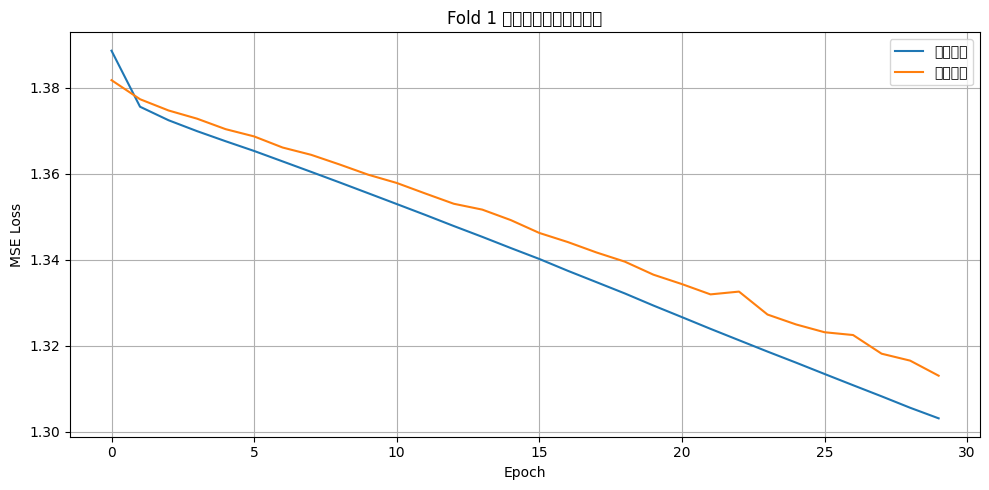

706/706 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step
✅ 验证集上的加权 R² Score: 0.052552
706/706 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step
✅ 测试集上的加权 R² Score: 0.047110
=================== Fold 2 ===================


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 79)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 10, 79, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 78, 4)      │            12 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 312)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,589 (377.30 KB)

 Trainable params: 96,589 (377.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1352/2821 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - loss: 1.4245

KeyboardInterrupt: 

In [9]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import os

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 1024
EPOCHS = 30
MODEL_PATH = 'cnn_lstm_model_no_lag.keras'

# ==============================
# 构造特征名（只用原始 feature）
features = [f'feature_{i:02d}' for i in range(79)]
NUM_FEATURES = len(features)  # 79

# ==============================
# 按照 symbol_id/date_id/time_id 排序
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)        # [样本数, SEQ_LEN, 79]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 构建模型：Conv1D + LSTM
def build_conv_fusion_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)  # [batch, seq_len, 79]
    
    x = Reshape((input_shape[0], 79, 1))(inputs)  # [batch, seq_len, 79, 1]

    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)  # [batch, seq_len, 78, 4]
    x = TimeDistributed(Flatten())(x)  # [batch, seq_len, 78*4] = [batch, seq_len, 312]

    x = LSTM(64, return_sequences=False)(x)
    outputs = Dense(1)(x)

    return Model(inputs, outputs)

# ==============================
# 五折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
r2_scores_val = []
r2_scores_test = []

for train_index, val_index in kf.split(X):
    print(f"=================== Fold {fold} ===================")
    
    # 划分训练集和验证集
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]
    w_train, w_val = weights[train_index], weights[val_index]
    
    # 划分测试集（假设使用最后 20% 数据作为测试集）
    test_start = int(len(X) * 0.8)
    X_test, y_test, w_test = X[test_start:], y[test_start:], weights[test_start:]

    # 构建和编译模型
    model = build_conv_fusion_cnn_lstm(X_train.shape[1:])
    model.compile(optimizer=Adam(learning_rate=2e-5), loss='mse')
    model.summary()

    # 回调函数
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=2e-6, verbose=1),
        ModelCheckpoint(filepath=MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
    ]
    
    # 模型训练
    history = model.fit(
        X_train, y_train,
        sample_weight=w_train,
        validation_data=(X_val, y_val, w_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )
    
    # 损失曲线可视化
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='训练损失')
    plt.plot(history.history['val_loss'], label='验证损失')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'Fold {fold} 训练过程中的损失变化')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # R² 加权评估函数
    def weighted_r2_score(y_true, y_pred, weight):
        y_bar = np.average(y_true, weights=weight)
        ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
        ss_res = np.sum(weight * (y_true - y_pred) ** 2)
        return 1 - ss_res / ss_tot

    # 验证集评估
    y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()
    r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
    print(f"✅ 验证集上的加权 R² Score: {r2_val:.6f}")
    r2_scores_val.append(r2_val)

    # 测试集评估
    y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE).squeeze()
    r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
    print(f"✅ 测试集上的加权 R² Score: {r2_test:.6f}")
    r2_scores_test.append(r2_test)

    fold += 1

# 计算平均 R² 得分
print(f"\n平均验证集 R²: {np.mean(r2_scores_val):.6f}")
print(f"平均测试集 R²: {np.mean(r2_scores_test):.6f}")

# 保存最终模型（可以选择性地保存）
model.save(MODEL_PATH)
print(f"✅ 模型已保存至 {MODEL_PATH}")


In [ ]:
from sklearn.model_selection import KFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
import os

# ==============================
# Parameters
SEQ_LEN = 10
BATCH_SIZE = 1024
EPOCHS = 30
MODEL_PATH = 'cnn_lstm_model_fold_{fold}.keras'

# ==============================
# Feature names
features = []
for i in range(79):
    features.append(f'feature_{i:02d}')
    features.append(f'factor_{i:02d}_lag1')  # Each feature corresponding to a lag feature

NUM_FEATURES = len(features)  # 158

# ==============================
# Sort data
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# Create sequences
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)  # [samples, SEQ_LEN, 158]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ Data shapes: X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_index, val_index) in enumerate(kf.split(X)):
    print(f"### Training Fold {fold + 1} ###")

    # Split into train and validation for this fold
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]
    w_train, w_val = weights[train_index], weights[val_index]

    print(f"Train Shape: {X_train.shape}, Val Shape: {X_val.shape}")

    # ==============================
    # Build model: Conv1D + LSTM
    def build_conv_fusion_cnn_lstm(input_shape):
        # input_shape: (SEQ_LEN, 158)
        inputs = Input(shape=input_shape)  # [batch, seq_len, 158]
        
        # 1. reshape: reshape each time step into 79x2
        x = Reshape((input_shape[0], 79, 2))(inputs)  # [batch, seq_len, 79, 2]

        # 2. Convolution: Conv1D for each pair of features
        x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)  # [batch, seq_len, 79, 1 → 4]

        # 3. Flatten
        x = TimeDistributed(Flatten())(x)  # [batch, seq_len, 4*78] = [batch, seq_len, 316]

        # 4. LSTM to extract sequential features
        x = LSTM(64, return_sequences=False)(x)

        # 5. Regression output
        outputs = Dense(1)(x)
        return Model(inputs, outputs)

    # ==============================
    # Compile model
    model = build_conv_fusion_cnn_lstm(X_train.shape[1:])
    model.compile(
        optimizer=Adam(learning_rate=2e-5),
        loss='mse'
    )
    model.summary()

    # ==============================
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=MODEL_PATH.format(fold=fold+1),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    # ==============================
    # Train model
    history = model.fit(
        X_train, y_train,
        sample_weight=w_train,
        validation_data=(X_val, y_val, w_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    # ==============================
    # Plot loss curves for each fold
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label=f'Fold {fold + 1} Train Loss')
    plt.plot(history.history['val_loss'], label=f'Fold {fold + 1} Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'Training and Validation Loss for Fold {fold + 1}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ==============================
    # Evaluate on validation set
    y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()

    def weighted_r2_score(y_true, y_pred, weight):
        y_bar = np.average(y_true, weights=weight)
        ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
        ss_res = np.sum(weight * (y_true - y_pred) ** 2)
        return 1 - ss_res / ss_tot

    r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
    print(f"✅ Fold {fold + 1} Validation R² Score: {r2_val:.6f}")
    fold_results.append(r2_val)

    # ==============================
    # Save the best model for this fold
    model.save(MODEL_PATH.format(fold=fold+1))
    print(f"✅ Model for Fold {fold + 1} saved to {MODEL_PATH.format(fold=fold+1)}")

# ==============================
# Average R² Score Across Folds
average_r2 = np.mean(fold_results)
print(f"✅ Average R² Score Across 5 Folds: {average_r2:.6f}")


In [4]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import os

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 2048
EPOCHS = 3
MODEL_PATH = 'cnn_lstm_model.keras'

# ==============================
# 构造特征名
features = []
for i in range(79):
    features.append(f'feature_{i:02d}')
    features.append(f'factor_{i:02d}_lag1')  # 每个 feature 对应一个 lag 特征

NUM_FEATURES = len(features)  # 158

# ==============================

df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)  # [样本数, SEQ_LEN, 158]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 划分训练集、验证集、测试集 (8:1:1)
num_samples = len(X)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)

X_train, y_train, w_train = X[:train_end], y[:train_end], weights[:train_end]
X_val, y_val, w_val = X[train_end:val_end], y[train_end:val_end], weights[train_end:val_end]
X_test, y_test, w_test = X[val_end:], y[val_end:], weights[val_end:]

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")

# ==============================
# 构建模型：Conv1D + LSTM
def build_conv_fusion_cnn_lstm(input_shape):
    # input_shape: (SEQ_LEN, 158)
    inputs = Input(shape=input_shape)  # [batch, seq_len, 158]
    
    # 1. reshape: 每个时间点变成 79x2
    x = Reshape((input_shape[0], 79, 2))(inputs)  # [batch, seq_len, 79, 2]

    # 2. 卷积合并：对每对特征做 Conv1D
    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)  # [batch, seq_len, 79, 1 → 4]

    # 3. 展平为向量
    x = TimeDistributed(Flatten())(x)  # [batch, seq_len, 4*78] = [batch, seq_len, 316]

    # 4. LSTM 提取时序特征
    x = LSTM(64, return_sequences=False)(x)

    # 5. 回归输出
    outputs = Dense(1)(x)
    return Model(inputs, outputs)

# ==============================
# 编译模型并训练
model = build_conv_fusion_cnn_lstm(X_train.shape[1:])
model.compile(optimizer='adam', loss='mse')
model.summary()


Processing sequences: 100%|██████████| 3765/3765 [00:20<00:00, 186.81it/s]


✅ 数据形状 X: (3610635, 10, 158), y: (3610635,), weights: (3610635,)
训练集: (2888508, 10, 158), 验证集: (361063, 10, 158), 测试集: (361064, 10, 158)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 158)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 79, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 78, 4)      │            20 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 312)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,597 (377.33 KB)

 Trainable params: 96,597 (377.33 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_val, y_val, w_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


# ==============================
# 在验证集上评估
y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()

def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
print(f"✅ 验证集上的加权 R² Score: {r2_val:.6f}")

# ==============================
# 在测试集上评估
y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE).squeeze()

r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
print(f"✅ 测试集上的加权 R² Score: {r2_test:.6f}")

# ==============================
# 保存模型
model.save(MODEL_PATH)
print(f"✅ 模型已保存至 {MODEL_PATH}")

Epoch 1/3
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 140s 96ms/step - loss: 1.4308 - val_loss: 1.1923
Epoch 2/3
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 124s 88ms/step - loss: 1.4029 - val_loss: 1.1940
Epoch 3/3
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 130s 92ms/step - loss: 1.3682 - val_loss: 1.1955
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step
✅ 验证集上的加权 R² Score: 0.000069
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step
✅ 测试集上的加权 R² Score: 0.004045
✅ 模型已保存至 cnn_lstm_model.keras


In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
EPOCHS = 20

# ========== 设置回调函数 ==========
callbacks = [
    EarlyStopping(
        monitor='val_loss',         # 监控验证集损失
        patience=5,                 # 连续 5 次不提升就停止
        restore_best_weights=True  # 恢复到最优模型
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                 # 学习率缩小为原来的一半
        patience=3,                 # 连续 3 次不提升就缩小学习率
        min_lr=1e-6,                # 最小学习率阈值
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]




In [7]:
# ========== 开始训练 ==========
model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_val, y_val, w_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks
)

# model.fit(
#     X_train, y_train,
#     sample_weight=w_train,
#     validation_data=(X_val, y_val, w_val),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     verbose=1
# )


# ==============================
# 在验证集上评估
y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()

def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
print(f"✅ 验证集上的加权 R² Score: {r2_val:.6f}")

# ==============================
# 在测试集上评估
y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE).squeeze()

r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
print(f"✅ 测试集上的加权 R² Score: {r2_test:.6f}")

# ==============================
# 保存模型
model.save(MODEL_PATH)
print(f"✅ 模型已保存至 {MODEL_PATH}")

Epoch 1/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 1.3251
Epoch 1: val_loss improved from inf to 1.21746, saving model to cnn_lstm_model.keras
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 123s 86ms/step - loss: 1.3251 - val_loss: 1.2175 - learning_rate: 0.0010
Epoch 2/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 1.2973
Epoch 2: val_loss did not improve from 1.21746
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 124s 88ms/step - loss: 1.2973 - val_loss: 1.2334 - learning_rate: 0.0010
Epoch 3/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 1.2659
Epoch 3: val_loss did not improve from 1.21746
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 130s 92ms/step - loss: 1.2659 - val_loss: 1.2508 - learning_rate: 0.0010
Epoch 4/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1.2402
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_loss did not improve from 1.21746
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 121s 86ms/step - loss: 1.2402 - val_loss: 1.2723 - learning_rate: 0.0010
E

Processing sequences: 100%|██████████| 3765/3765 [00:06<00:00, 558.45it/s]


✅ 数据形状 X: (3610635, 10, 158), y: (3610635,), weights: (3610635,)
训练集: (2888508, 10, 158), 验证集: (361063, 10, 158), 测试集: (361064, 10, 158)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10, 158)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 10, 79, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 78, 4)      │            20 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 312)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,597 (377.33 KB)

 Trainable params: 96,597 (377.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 2.2578
Epoch 1: val_loss improved from inf to 1.20873, saving model to cnn_lstm_model.keras
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 137s 95ms/step - loss: 2.2574 - val_loss: 1.2087 - learning_rate: 2.0000e-05
Epoch 2/30
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 1.4406
Epoch 2: val_loss improved from 1.20873 to 1.19887, saving model to cnn_lstm_model.keras
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 120s 85ms/step - loss: 1.4406 - val_loss: 1.1989 - learning_rate: 2.0000e-05
Epoch 3/30
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 1.4428
Epoch 3: val_loss improved from 1.19887 to 1.19459, saving model to cnn_lstm_model.keras
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 122s 87ms/step - loss: 1.4428 - val_loss: 1.1946 - learning_rate: 2.0000e-05
Epoch 4/30
1410/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 1.4343
Epoch 4: val_loss improved from 1.19459 to 1.19315, saving model to cnn_lstm_model.keras
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 125s 88ms/ste

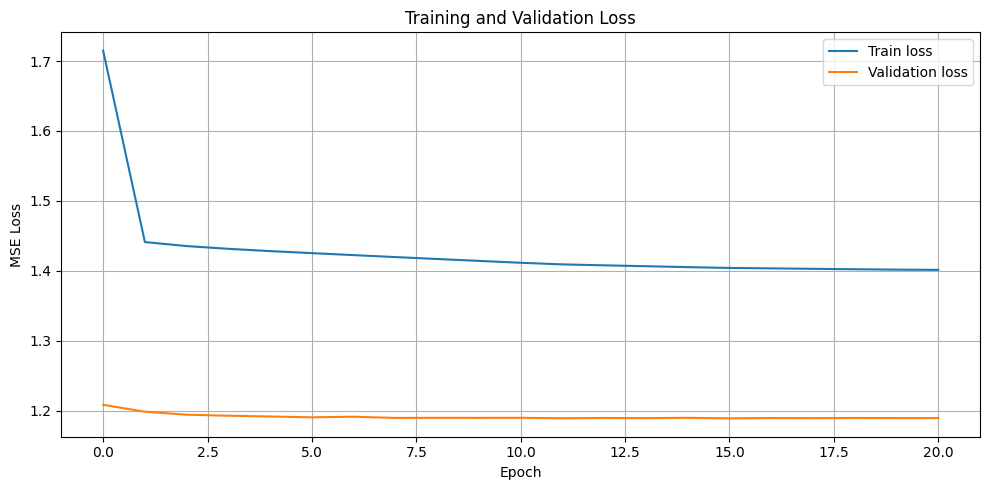

177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step
✅ Validation set R² Score: 0.005193
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step
✅ Test set R² Score: 0.003993
✅ 模型已保存至 cnn_lstm_model.keras


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from sklearn.model_selection import KFold
import os

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 2048
EPOCHS = 30
FOLDS = 5

# ==============================
# 构造特征名
features = []
for i in range(79):
    features.append(f'feature_{i:02d}')
    features.append(f'factor_{i:02d}_lag1')  # 每个 feature 对应一个 lag 特征

NUM_FEATURES = len(features)  # 158

# ==============================
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 构建模型
def build_conv_fusion_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)
    x = Reshape((input_shape[0], 79, 2))(inputs)
    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)
    x = TimeDistributed(Flatten())(x)
    x = LSTM(64, return_sequences=False)(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs)

# ==============================
# 加权 R² 计算
def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

# ==============================
# 5 折交叉验证
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=42)
fold_r2_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n🔁 Fold {fold + 1}/{FOLDS}")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    w_train, w_val = weights[train_idx], weights[val_idx]

    model = build_conv_fusion_cnn_lstm(X.shape[1:])
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ]

    history = model.fit(
        X_train, y_train,
        sample_weight=w_train,
        validation_data=(X_val, y_val, w_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()
    r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
    fold_r2_scores.append(r2_val)
    print(f"✅ Fold {fold + 1} Validation R²: {r2_val:.6f}")

# ==============================
# 总结 R² 结果
print("\n📊 五折验证 R² 分数:")                                                                                                                                                                       
for i, r2 in enumerate(fold_r2_scores, 1):
    print(f"Fold {i}: {r2:.6f}")
print(f"平均 R²: {np.mean(fold_r2_scores):.6f}, 标准差: {np.std(fold_r2_scores):.6f}")


Processing sequences: 100%|██████████| 3765/3765 [00:07<00:00, 524.43it/s]


✅ 数据形状 X: (3610635, 10, 158), y: (3610635,), weights: (3610635,)

🔁 Fold 1/5
Epoch 1/30
 250/1411 ━━━━━━━━━━━━━━━━━━━━ 1:17 67ms/step - loss: 1.4361

Processing sequences: 100%|██████████| 3765/3765 [00:05<00:00, 708.32it/s] 


✅ 数据形状 X: (3610635, 10, 79), y: (3610635,), weights: (3610635,)
训练集: (2888508, 10, 79), 验证集: (361063, 10, 79), 测试集: (361064, 10, 79)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 79)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 10, 79, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 78, 4)      │            12 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 312)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,589 (377.30 KB)

 Trainable params: 96,589 (377.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1410/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 1.4458
Epoch 1: val_loss improved from inf to 1.19553, saving model to cnn_lstm_model_no_lag.keras
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 131s 91ms/step - loss: 1.4458 - val_loss: 1.1955 - learning_rate: 0.0010
Epoch 2/30
1410/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.4146
Epoch 2: val_loss improved from 1.19553 to 1.19544, saving model to cnn_lstm_model_no_lag.keras
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 113s 80ms/step - loss: 1.4146 - val_loss: 1.1954 - learning_rate: 0.0010
Epoch 3/30
1410/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 1.3837
Epoch 3: val_loss did not improve from 1.19544
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 113s 80ms/step - loss: 1.3837 - val_loss: 1.2073 - learning_rate: 0.0010
Epoch 4/30
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1.3503
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_loss did not improve from 1.19544
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 111s 79ms/step - l

C:\Users\36119\AppData\Local\Temp\ipykernel_66032\1470800344.py:116: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_66032\1470800344.py:116: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_66032\1470800344.py:116: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_66032\1470800344.py:116: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_66032\1470800344.py:116: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  plt.tight_layout()
C:\Users\36119\AppData\Local\Temp\ipykernel_66032\1470800344.py:116: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}

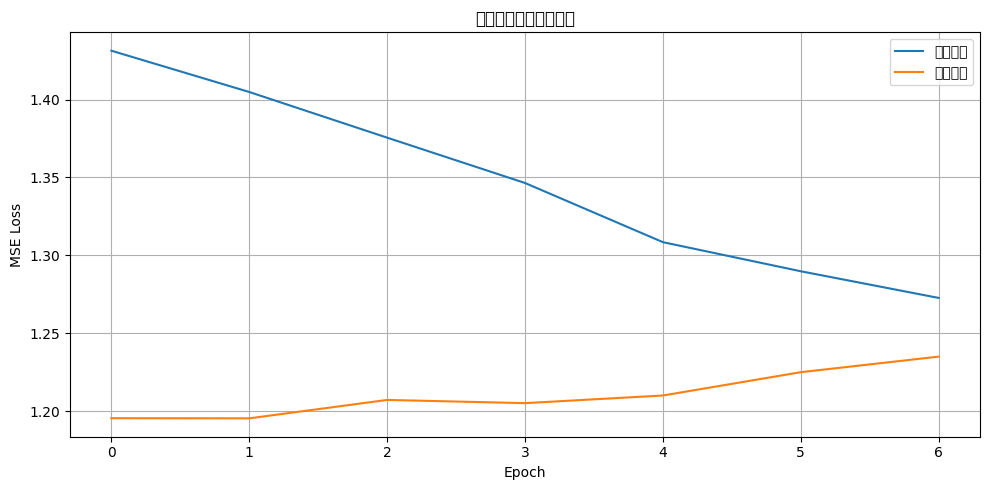

177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step
✅ 验证集上的加权 R² Score: 0.000138
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
✅ 测试集上的加权 R² Score: 0.003873
✅ 模型已保存至 cnn_lstm_model_no_lag.keras


In [12]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 2048
EPOCHS = 30
MODEL_PATH = 'cnn_lstm_model_no_lag.keras'

# ==============================
# 构造特征名（只用原始 feature）
features = [f'feature_{i:02d}' for i in range(79)]
NUM_FEATURES = len(features)  # 79

# ==============================
# 按照 symbol_id/date_id/time_id 排序
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

# ==============================
# 构造序列样本
X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)        # [样本数, SEQ_LEN, 79]
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 划分训练集、验证集、测试集 (8:1:1)
num_samples = len(X)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)

X_train, y_train, w_train = X[:train_end], y[:train_end], weights[:train_end]
X_val, y_val, w_val = X[train_end:val_end], y[train_end:val_end], weights[train_end:val_end]
X_test, y_test, w_test = X[val_end:], y[val_end:], weights[val_end:]

print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}, 测试集: {X_test.shape}")

# ==============================
# 构建模型：Conv1D + LSTM
def build_conv_fusion_cnn_lstm(input_shape):
    inputs = Input(shape=input_shape)  # [batch, seq_len, 79]
    
    x = Reshape((input_shape[0], 79, 1))(inputs)  # [batch, seq_len, 79, 1]

    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)  # [batch, seq_len, 78, 4]
    x = TimeDistributed(Flatten())(x)  # [batch, seq_len, 78*4] = [batch, seq_len, 312]

    x = LSTM(64, return_sequences=False)(x)
    outputs = Dense(1)(x)

    return Model(inputs, outputs)

# ==============================
# 构建、编译模型
model = build_conv_fusion_cnn_lstm(X_train.shape[1:])
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse'
)
model.summary()

# ==============================
# 回调函数
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=2e-6, verbose=1),
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]

# ==============================
# 模型训练
history = model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_val, y_val, w_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks
)

# ==============================
# 损失曲线可视化
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='训练损失')
plt.plot(history.history['val_loss'], label='验证损失')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('训练过程中的损失变化')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# R² 加权评估函数
def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

# ==============================
# 验证集评估
y_pred_val = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()
r2_val = weighted_r2_score(y_val, y_pred_val, w_val)
print(f"✅ 验证集上的加权 R² Score: {r2_val:.6f}")

# 测试集评估
y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE).squeeze()
r2_test = weighted_r2_score(y_test, y_pred_test, w_test)
print(f"✅ 测试集上的加权 R² Score: {r2_test:.6f}")

# ==============================
# 保存最终模型（可省略，已经通过 ModelCheckpoint 保存了最优模型）
model.save(MODEL_PATH)
print(f"✅ 模型已保存至 {MODEL_PATH}")


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, TimeDistributed, Reshape, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# ==============================
# 参数定义
SEQ_LEN = 10
BATCH_SIZE = 2048
EPOCHS = 30
NUM_FOLDS = 5
FEATURES = [f'feature_{i:02d}' for i in range(79)]

# ==============================
# 构造序列样本
df_new = df_new.sort_values(['symbol_id', 'date_id', 'time_id'])

X, y, weights = [], [], []
grouped = df_new.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[FEATURES].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"✅ 样本维度: X={X.shape}, y={y.shape}, weights={weights.shape}")

# ==============================
# 构建模型函数
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Reshape((input_shape[0], input_shape[1], 1))(inputs)
    x = TimeDistributed(Conv1D(filters=4, kernel_size=2, activation='relu'))(x)
    x = TimeDistributed(Flatten())(x)
    x = LSTM(64, return_sequences=False)(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs)

# ==============================
# R² 加权评估函数
def weighted_r2_score(y_true, y_pred, weight):
    y_bar = np.average(y_true, weights=weight)
    ss_tot = np.sum(weight * (y_true - y_bar) ** 2)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    return 1 - ss_res / ss_tot

# ==============================
# 5 折交叉验证
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_r2_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n📂 开始第 {fold+1} 折训练")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    w_train, w_val = weights[train_idx], weights[val_idx]

    model = build_model(input_shape=X.shape[1:])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        sample_weight=w_train,
        validation_data=(X_val, y_val, w_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    # 绘制损失曲线
    plt.plot(history.history['loss'], label=f'Fold {fold+1} Train')
    plt.plot(history.history['val_loss'], label=f'Fold {fold+1} Val')

    # 验证集评估
    y_pred = model.predict(X_val, batch_size=BATCH_SIZE).squeeze()
    r2 = weighted_r2_score(y_val, y_pred, w_val)
    print(f"🎯 Fold {fold+1} 验证集加权 R² Score: {r2:.6f}")
    fold_r2_scores.append(r2)

# ==============================
# 平均 R² 分数输出
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("各折训练和验证损失曲线")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n🎯 各折加权 R² Scores:", [f"{r:.6f}" for r in fold_r2_scores])
print(f"✅ 平均加权 R² Score: {np.mean(fold_r2_scores):.6f} ± {np.std(fold_r2_scores):.6f}")


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import os

# 假设你已有 DataFrame：data
# 替换以下行读取自己的数据
# data = pd.read_csv('your_data.csv')

# ==============================
# 参数定义
SEQ_LEN = 10
NUM_FEATURES = 79
BATCH_SIZE = 2048
EPOCHS = 20
MODEL_PATH = 'cnn_lstm_model.keras'

# ==============================
# 构造序列样本
features = [f'feature_{i:02d}' for i in range(NUM_FEATURES)]

# 确保按时间排序
data = data.sort_values(['symbol_id', 'date_id', 'time_id'])

sequences, targets = [], []
grouped = data.groupby(['symbol_id', 'date_id'])

X, y, weights = [], [], []

grouped = data.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values  # 获取每一行的权重
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        # 构造滑动窗口特征并加入权重
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])  # 预测末尾那一时刻的值
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])  # 使用窗口末尾的权重

# 转换为 numpy 数组
X = np.array(X, dtype=np.float32)  # [n_samples, SEQ_LEN, NUM_FEATURES]
y = np.array(y, dtype=np.float32)  # [n_samples]
weights = np.array(weights, dtype=np.float32)  # [n_samples]

print(f"数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")




Processing sequences: 100%|██████████| 3765/3765 [00:04<00:00, 872.38it/s] 


数据形状 X: (3610635, 10, 79), y: (3610635,), weights: (3610635,)


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import os

# 假设你已有 DataFrame：data
# 替换以下行读取自己的数据
# data = pd.read_csv('your_data.csv')

# ==============================
# 参数定义
SEQ_LEN = 10
NUM_FEATURES = 79
BATCH_SIZE = 2048
EPOCHS = 20
MODEL_PATH = 'cnn_lstm_model.keras'

# ==============================
# 构造特征名
features = [f'feature_{i:02d}' for i in range(79)]  # 原始79特征
pc_features = [f'PC{i}' for i in range(1, 11)]       # PC1 到 PC10
features += pc_features                              # 合并
NUM_FEATURES = len(features)                          # 现在是 89 个特征

# ==============================
# 排序并构造样本
data = data.sort_values(['symbol_id', 'date_id', 'time_id'])

X, y, weights = [], [], []
grouped = data.groupby(['symbol_id', 'date_id'])

for _, group in tqdm(grouped, desc="Processing sequences"):
    arr = group[features].values
    target = group['responder_6'].values
    weight = group['weight'].values
    if len(arr) >= SEQ_LEN:
        num_samples = len(arr) - SEQ_LEN + 1
        X.extend([arr[i:i+SEQ_LEN] for i in range(num_samples)])
        y.extend([target[i+SEQ_LEN-1] for i in range(num_samples)])
        weights.extend([weight[i+SEQ_LEN-1] for i in range(num_samples)])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
weights = np.array(weights, dtype=np.float32)

print(f"数据形状 X: {X.shape}, y: {y.shape}, weights: {weights.shape}")

# ==============================
# 划分训练集和验证集
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y, weights, test_size=0.2, shuffle=False)

Processing sequences: 100%|██████████| 3765/3765 [00:04<00:00, 829.06it/s] 


数据形状 X: (3610635, 10, 89), y: (3610635,), weights: (3610635,)


In [18]:


# ==============================
# 模型构建
# def build_cnn_lstm_model(seq_len=SEQ_LEN, num_features=NUM_FEATURES):
#     inputs = tf.keras.Input(shape=(seq_len, num_features))
#     x = layers.Conv1D(64, 3, padding='same', activation='relu')(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
#     x = layers.MaxPooling1D(pool_size=2)(x)
#     x = layers.LSTM(64, return_sequences=False)(x)
#     x = layers.Dense(32, activation='relu')(x)
#     x = layers.Dropout(0.3)(x)
#     output = layers.Dense(1, activation='linear')(x)
#     model = tf.keras.Model(inputs, output)
#     model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#     return model

# model = build_cnn_lstm_model()
# model.summary()


from tensorflow.keras.optimizers import Adam

# ==============================
# 模型构建（含学习率设置）
def build_cnn_lstm_model(seq_len=SEQ_LEN, num_features=NUM_FEATURES, learning_rate=0.0005):
    inputs = tf.keras.Input(shape=(seq_len, num_features))
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='linear')(x)

    model = tf.keras.Model(inputs, output)
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

# 构建模型，指定学习率
model = build_cnn_lstm_model(learning_rate=0.0005)
model.summary()


# ==============================
# 模型训练
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, save_best_only=True)
    ]
)

# ==============================
# 保存最终模型
model.save(MODEL_PATH)
print(f"模型已保存至 {MODEL_PATH}")

# ==============================
# 自定义带权重 R² 分数计算
def weighted_r2_score(y_true, y_pred, weight):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weight = np.asarray(weight)

    weighted_mean = np.sum(weight * y_true) / np.sum(weight)
    ss_res = np.sum(weight * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weight * (y_true - weighted_mean) ** 2)

    r2 = 1 - ss_res / (ss_tot + 1e-38)
    return r2

# ==============================
# 验证集评估
y_pred_val = model.predict(X_val).reshape(-1)
r2 = weighted_r2_score(y_val, y_pred_val, w_val)
print(f"✅ 验证集上的加权 R² Score: {r2:.6f}")

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 10, 89)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 10, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,897 (253.50 KB)

 Trainable params: 64,769 (253.00 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - loss: 0.6112 - mae: 0.5238 - val_loss: 0.6285 - val_mae: 0.5346
Epoch 2/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - loss: 0.6069 - mae: 0.5222 - val_loss: 0.6297 - val_mae: 0.5341
Epoch 3/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - loss: 0.5956 - mae: 0.5191 - val_loss: 0.6282 - val_mae: 0.5338
Epoch 4/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - loss: 0.5887 - mae: 0.5175 - val_loss: 0.6685 - val_mae: 0.5490
Epoch 5/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - loss: 0.5781 - mae: 0.5146 - val_loss: 0.6433 - val_mae: 0.5376
Epoch 6/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - loss: 0.5713 - mae: 0.5131 - val_loss: 0.6512 - val_mae: 0.5412
Epoch 7/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - loss: 0.5641 - mae: 0.5112 - val_loss: 0.6831 - val_mae: 0.5527
Epoch 8/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - loss: 0.5536 - mae: 0.5079 - val_loss: 0.6657 - val_mae: 0.5443
模型已保存至 cnn_lstm_model.ke

In [17]:
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, GlobalAveragePooling1D, Flatten, Concatenate
from tensorflow.keras.models import Model
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ========== 第一层模型 ==========
def build_cnn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs, name='cnn_model')

def build_lstm_model(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(64, return_sequences=False)(inputs)
    outputs = Dense(1)(x)
    return Model(inputs, outputs, name='lstm_model')

def build_mlp_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Flatten()(inputs)
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs, name='mlp_model')

input_shape = X_train.shape[1:]

# 实例化模型
cnn_model = build_cnn_model(input_shape)
lstm_model = build_lstm_model(input_shape)
mlp_model = build_mlp_model(input_shape)

# 编译
for model in [cnn_model, lstm_model, mlp_model]:
    model.compile(optimizer='adam', loss='mse')

# ========== 训练每个模型 ==========
cnn_model.fit(X_train, y_train, sample_weight=w_train, validation_data=(X_val, y_val, w_val),
              epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

lstm_model.fit(X_train, y_train, sample_weight=w_train, validation_data=(X_val, y_val, w_val),
               epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

mlp_model.fit(X_train, y_train, sample_weight=w_train, validation_data=(X_val, y_val, w_val),
              epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

# ========== 第二层模型输入 ==========
train_preds = np.stack([
    cnn_model.predict(X_train, batch_size=BATCH_SIZE).squeeze(),
    lstm_model.predict(X_train, batch_size=BATCH_SIZE).squeeze(),
    mlp_model.predict(X_train, batch_size=BATCH_SIZE).squeeze()
], axis=1)

val_preds = np.stack([
    cnn_model.predict(X_val, batch_size=BATCH_SIZE).squeeze(),
    lstm_model.predict(X_val, batch_size=BATCH_SIZE).squeeze(),
    mlp_model.predict(X_val, batch_size=BATCH_SIZE).squeeze()
], axis=1)

# ========== 第二层模型（Ridge 回归） ==========
stacker = Ridge(alpha=1.0)
stacker.fit(train_preds, y_train, sample_weight=w_train)

# ========== 评估 ==========
stacked_val_preds = stacker.predict(val_preds)
r2 = r2_score(y_val, stacked_val_preds, sample_weight=w_val)
print(f"Stacked model validation R² score: {r2:.4f}")


Epoch 1/20
1411/1411 - 9s - 6ms/step - loss: 1.5751 - val_loss: 1.2836
Epoch 2/20
1411/1411 - 8s - 5ms/step - loss: 1.4632 - val_loss: 1.2773
Epoch 3/20
1411/1411 - 8s - 5ms/step - loss: 1.4579 - val_loss: 1.1670
Epoch 4/20
1411/1411 - 8s - 6ms/step - loss: 1.4379 - val_loss: 1.1633
Epoch 5/20
1411/1411 - 8s - 6ms/step - loss: 1.4321 - val_loss: 1.1736
Epoch 6/20
1411/1411 - 8s - 6ms/step - loss: 1.4256 - val_loss: 1.1776
Epoch 7/20
1411/1411 - 8s - 6ms/step - loss: 1.4221 - val_loss: 1.2550
Epoch 8/20
1411/1411 - 8s - 6ms/step - loss: 1.4149 - val_loss: 1.1650
Epoch 9/20
1411/1411 - 8s - 6ms/step - loss: 1.4166 - val_loss: 1.1670
Epoch 10/20
1411/1411 - 9s - 6ms/step - loss: 1.4064 - val_loss: 1.1999
Epoch 11/20
1411/1411 - 8s - 6ms/step - loss: 1.4021 - val_loss: 1.1645
Epoch 12/20
1411/1411 - 9s - 6ms/step - loss: 1.3995 - val_loss: 1.2316
Epoch 13/20
1411/1411 - 9s - 6ms/step - loss: 1.3945 - val_loss: 1.1903
Epoch 14/20
1411/1411 - 9s - 6ms/step - loss: 1.3968 - val_loss: 1.1598
E